# MySQL Sample Data bases
- https://dev.mysql.com/doc/index-other.html
- employee
    - https://dev.mysql.com/doc/employee/en/
    - https://dev.mysql.com/doc/employee/en/employees-introduction.html
    - The Employees sample database was developed by Patrick Crews and Giuseppe Maxia and provides a combination of a large base of data (approximately 160MB) spread over six separate tables and consisting of 4 million records in total. The structure is compatible with a wide range of storage engine types. Through an included data file, support for partitioned tables is also provided.
    - In addition to the base data, the Employees database also includes a suite of tests that can be executed across the test data to ensure the integrity of the data that you have loaded. This should help ensure the quality of the data during initial load, and can be used after usage to ensure that no changes have been made to the database during testing.
    - The Employees database is available from Employees DB on GitHub. You can download a prepackaged archive of the data, or access the information through Git.
    - To use the Zip archive package, download the archive and unpack it using WinZip or another tool that can read .zip files, then change location into the unpacked package directory. For example, using unzip, execute these commands:
        - $> unzip test_db-master.zip
        - $> cd test_db-master/
    - Import into MySQL with mysql command
        - $> mysql -t < employees.sql
    - test installation
        - $> time mysql -t < test_employees_sha.sql
    - Structure of Databases
        - https://dev.mysql.com/doc/employee/en/sakila-structure.html
    - Schema
        - https://dev.mysql.com/doc/employee/en/images/employees-schema.png

## World Database
- https://dev.mysql.com/doc/world-setup/en/
- set of three tables:
    - country: Information about countries of the world.
    - city: Information about some of the cities in those countries.
    - countrylanguage: Languages spoken in each country.
- The world.sql file containing the world database is available for download at https://dev.mysql.com/doc/index-other.html. The file is provided as a compressed tar file or Zip archive.
- To install the world sample database, follow these steps:
    - Download the installation archive to a temporary location such as C:\temp\ or /tmp/ and unpack it. Unpacking the archive results in a directory named world-db containing a single file named world.sql.
    - Connect to the MySQL server using the mysql command-line client with the following command:
        - $> mysql -u root -p
        - Enter your password when prompted. A non-root account can be used, provided that the account has privileges to create new databases.
    - Execute tht world.sql script to create database structure and insert the data using the following command:
        - mysql> SOURCE C:/temp/world.sql;
            - source /Users/du/dup/analytics/data/world-db/world.sql (mac)
            - source C:/analytics/data/world-db/world.sql (win)
        - Replace the path to the world.sql file with the actual path on your system.
        - On Windows, use slashes rather than backslashes when executing the SOURCE command.
    - To confirm that the sample world database is installed correctly, execute the following statements. You should see output similar to that shown here.
    - mysql> USE world;
    - show tables;
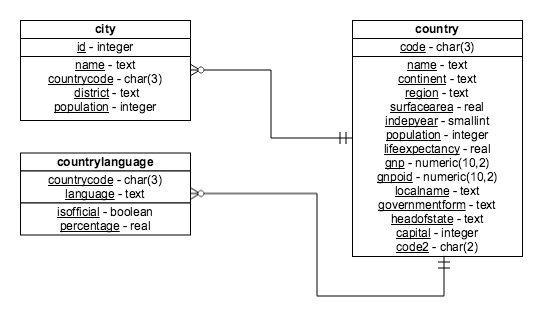

## Commands in mysql for world database
- https://gist.github.com/mdang/9a4a8063ebea3b829b8025746643ade1
- use world;
- show tables;
- select count(*) from city;
- select count(*) from country;
- select count(*) from countrylanguage;

# More commands
- select city.name, country.name from city, country where country.code = city.countryCode

- Using count, get the number of cities in the USA
- Find out what the population and average life expectancy for people in Argentina (ARG) is
- Using IS NOT NULL, ORDER BY, LIMIT, what country has the highest life expectancy?
- Using LEFT JOIN, ON, what is the capital of Spain (ESP)?
- Using LEFT JOIN, ON, list all the languages spoken in the 'Southeast Asia' region

##  MySQL sample database - Customers
- https://www.mysqltutorial.org/getting-started-with-mysql/mysql-sample-database/
- https://www.mysqltutorial.org/wp-content/uploads/2023/10/mysqlsampledatabase.zip
- Schema- MySQL Sample Database Schema :  The MySQL sample database schema consists of the following tables:
    - customers: stores customer’s data.
    - products: stores a list of scale model cars.
    - productlines: stores a list of product lines.
    - orders: stores sales orders placed by customers.
    - orderdetails: stores sales order line items for every sales order.
    - payments: stores payments made by customers based on their accounts.
    - employees: stores employee information and the organization structure such as who reports to whom.
    - offices: stores sales office data.
- Load into sql
    - mysql > source /Users/du/dup/analytics/data/mysqlsampledatabase.sql

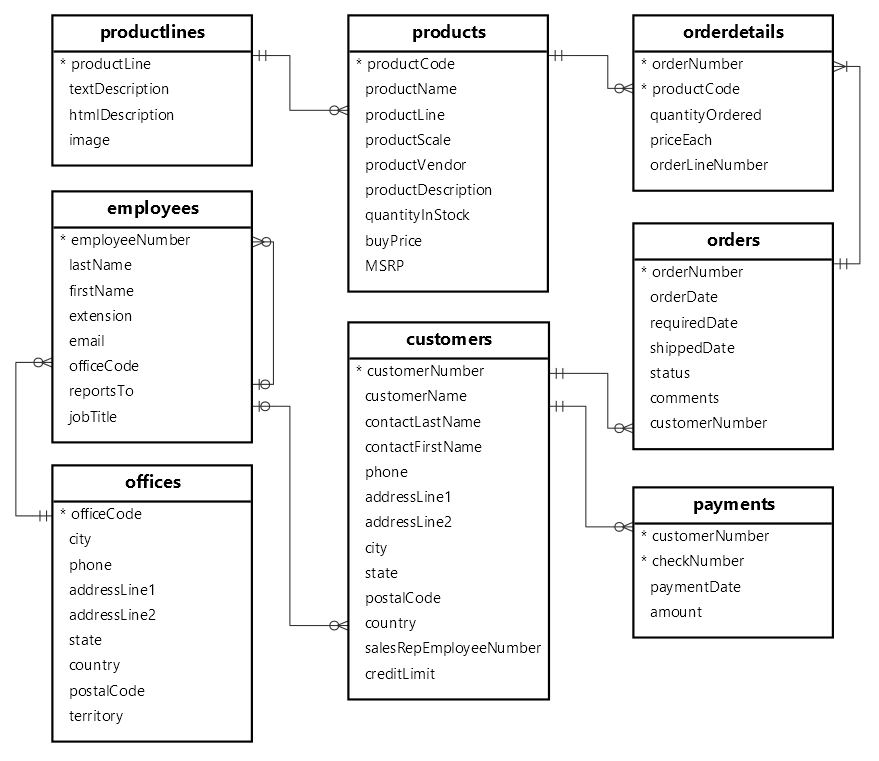

## SQL commands
- use classicmodels
- View all customers
    - select * from customers
- Show customer names and countries
    - select customerName, country from customers; 
- Find customers from France
    - SELECT customerName, city, country FROM customers WHERE country = 'France';

- Sort customers alphabetically
    - SELECT customerName FROM customers ORDER BY customerName;
- Display top 10 products
    - SELECT productName, buyPrice FROM products LIMIT 10;
- Filtering & Conditions
    - Products costing more than 50
        - SELECT productName, buyPrice FROM products WHERE buyPrice > 50;
    - Orders placed after 2004
        - SELECT orderNumber, orderDate FROM orders WHERE orderDate > '2004-12-31';
    - Customers from USA or Canada
        - SELECT customerName, country FROM customers WHERE country IN ('USA', 'Canada');
    - Employees with job title “Sales Rep”
        - SELECT firstName, lastName, jobTitle FROM employees WHERE jobTitle = 'Sales Rep';
    - Products containing “Ford”
        - SELECT productName FROM products WHERE productName LIKE '%Ford%';
- Aggregate Functions
    - Count total customers 
        - SELECT COUNT(*) AS total_customers FROM customers;
    - Average product price
        - SELECT AVG(buyPrice) AS average_price FROM products;
    - Highest payment amount
        - SELECT MAX(amount) AS highest_payment FROM payments;
    - Total payments received
        - SELECT SUM(amount) AS total_payments FROM payments;
    - Number of customers by country
        - SELECT country, COUNT(*) AS customer_count FROM customers GROUP BY country ORDER BY customer_count DESC;
### JOIN Queries
    - Show customer orders
        - SELECT c.customerName, o.orderNumber, o.orderDate FROM customers c JOIN orders o ON c.customerNumber = o.customerNumber;
    - Show order details with product names
        - SELECT o.orderNumber, p.productName, od.quantityOrdered FROM orderdetails od JOIN products p ON od.productCode = p.productCode JOIN orders o ON od.orderNumber = o.orderNumber;
    - Employees and their offices
        - SELECT e.firstName, e.lastName, o.city FROM employees e JOIN offices o ON e.officeCode = o.officeCode;
    - Customers and sales representatives
        - SELECT c.customerName, e.firstName, e.lastName FROM customers c JOIN employees e ON c.salesRepEmployeeNumber = e.employeeNumber;
    - Payments made by each customer
        - SELECT c.customerName, p.paymentDate, p.amount FROM customers c JOIN payments p ON c.customerNumber = p.customerNumber;

### GROUP BY & HAVING
    - Total orders by customer 
        - SELECT customerNumber,        COUNT(orderNumber) AS total_orders FROM orders GROUP BY customerNumber;
    - Customers with more than 5 orders
        - SELECT customerNumber,        COUNT(orderNumber) AS total_orders FROM orders GROUP BY customerNumber HAVING COUNT(orderNumber) > 5;
    - Average payment by country
        - SELECT c.country,        AVG(p.amount) AS avg_payment FROM customers c JOIN payments p ON c.customerNumber = p.customerNumber GROUP BY c.country;
### Subqueries
    - Customers who made payments above average
        - SELECT customerNumber, amount FROM payments WHERE amount > ( SELECT AVG(amount)    FROM payments );
    - Most expensive product
        SELECT productName, buyPrice FROM products WHERE buyPrice = ( SELECT MAX(buyPrice)    FROM products);

### Intermediate Challenges
    - Top 5 customers by payment amount
        - SELECT c.customerName,        SUM(p.amount) AS total_paid FROM customers c JOIN payments p ON c.customerNumber = p.customerNumber  GROUP BY c.customerName ORDER BY total_paid DESC LIMIT 5;
    - Monthly sales totals
        -SELECT YEAR(paymentDate) AS year,        MONTH(paymentDate) AS month,        SUM(amount) AS total_sales FROM payments GROUP BY YEAR(paymentDate), MONTH(paymentDate) ORDER BY year, month;
    - Products never ordered
        - SELECT productName FROM products WHERE productCode NOT IN ( SELECT productCode    FROM orderdetails);
    - Employee reporting structure
        - SELECT e.firstName AS employee,        m.firstName AS manager FROM employees e LEFT JOIN employees m ON e.reportsTo = m.employeeNumber;
    - Customers without payments
        - SELECT c.customerName FROM customers c LEFT JOIN payments p ON c.customerNumber = p.customerNumber WHERE p.customerNumber IS NULL;
### Advanced Practice Queries
    - Rank customers by total payments
        - SELECT c.customerName,        SUM(p.amount) AS total_paid,       RANK() OVER (ORDER BY SUM(p.amount) DESC) AS ranking FROM customers c JOIN payments p ON c.customerNumber = p.customerNumber GROUP BY c.customerName;
    - Running total of payments
        - SELECT paymentDate,        amount,       SUM(amount) OVER (ORDER BY paymentDate) AS running_total FROM payments;
    - Best-selling products
        - SELECT p.productName,        SUM(od.quantityOrdered) AS total_sold FROM products p JOIN orderdetails od ON p.productCode = od.productCode GROUP BY p.productName ORDER BY total_sold DESC;
    - Revenue generated per product
        - SELECT p.productName,        SUM(od.quantityOrdered * od.priceEach) AS revenue FROM products p JOIN orderdetails od ON p.productCode = od.productCode GROUP BY p.productName ORDER BY revenue DESC;
    - Top office by sales
        - SELECT o.city,        SUM(p.amount) AS total_sales FROM offices o JOIN employees e ON o.officeCode = e.officeCode JOIN customers c ON e.employeeNumber = c.salesRepEmployeeNumber JOIN payments p ON c.customerNumber = p.customerNumber GROUP BY o.city ORDER BY total_sales DESC;


### Practice Challenges (Try Yourself)
    - Easy
        - Find all customers from Germany.
        - List products with quantity in stock above 5000.
        - Find orders shipped after required date.
    - Medium
        - Find top 3 countries by revenue.
        - Show customers with no orders.
        - Calculate average order value.
    - Hard
        - Find month with highest sales.
        - Find repeat customers ordering in multiple years.
        - Create customer segmentation based on spending.
### Useful Learning Areas
    - You can practice:
    SELECT
    WHERE
    ORDER BY
    GROUP BY
    HAVING
    JOIN
    LEFT JOIN
    SUBQUERIES
    WINDOW FUNCTIONS
    CTEs
    CASE WHEN
    DATE FUNCTIONS

### Recommended Progression
    - Week 1 
        - Basic SELECT + WHERE + ORDER BY
    - Week 2
        - GROUP BY + Aggregations
    - Week 3
        - JOINs
    - Week 4
        - Subqueries + Window Functions
    - Week 5
        - Business Case SQL Problems

## Employee and Department table
- https://justinsomnia.org/2009/04/the-emp-and-dept-tables-for-mysql/
- https://gist.github.com/YujiShen/39f6ef573ada22b87998
- Oracle
- DROP TABLE IF EXISTS emp;
- CREATE TABLE emp (   empno INT PRIMARY KEY,  ename varchar(10) default NULL,  job varchar(9) default NULL,  mgr decimal(4,0) default NULL, hiredate date default NULL,  sal decimal(7,2) default NULL,  comm decimal(7,2) default NULL,  deptno decimal(2,0) default NULL);
- DROP TABLE IF EXISTS dept;
- CREATE TABLE dept (  deptno decimal(2,0) PRIMARY KEY,  dname varchar(14) default NULL,  loc varchar(13) default NULL);
- CREATE TABLE dept (  deptno INT PRIMARY KEY,  dname varchar(14) default NULL,  loc varchar(13) default NULL);
### emptable value
- emp
INSERT INTO emp VALUES ('7369','SMITH','CLERK','7902','1980-12-17','800.00',NULL,'20');
INSERT INTO emp VALUES ('7499','ALLEN','SALESMAN','7698','1981-02-20','1600.00','300.00','30');
INSERT INTO emp VALUES ('7521','WARD','SALESMAN','7698','1981-02-22','1250.00','500.00','30');
INSERT INTO emp VALUES ('7566','JONES','MANAGER','7839','1981-04-02','2975.00',NULL,'20');
INSERT INTO emp VALUES ('7654','MARTIN','SALESMAN','7698','1981-09-28','1250.00','1400.00','30');
INSERT INTO emp VALUES ('7698','BLAKE','MANAGER','7839','1981-05-01','2850.00',NULL,'30');
INSERT INTO emp VALUES ('7782','CLARK','MANAGER','7839','1981-06-09','2450.00',NULL,'10');
- 
INSERT INTO emp VALUES ('7788','SCOTT','ANALYST','7566','1982-12-09','3000.00',NULL,'20');
INSERT INTO emp VALUES ('7839','KING','PRESIDENT',NULL,'1981-11-17','5000.00',NULL,'10');
INSERT INTO emp VALUES ('7844','TURNER','SALESMAN','7698','1981-09-08','1500.00','0.00','30');
INSERT INTO emp VALUES ('7876','ADAMS','CLERK','7788','1983-01-12','1100.00',NULL,'20');
INSERT INTO emp VALUES ('7900','JAMES','CLERK','7698','1981-12-03','950.00',NULL,'30');
INSERT INTO emp VALUES ('7902','FORD','ANALYST','7566','1981-12-03','3000.00',NULL,'20');
INSERT INTO emp VALUES ('7934','MILLER','CLERK','7782','1982-01-23','1300.00',NULL,'10');
- dept
INSERT INTO dept VALUES ('10','ACCOUNTING','NEW YORK');
INSERT INTO dept VALUES ('20','RESEARCH','DALLAS');
INSERT INTO dept VALUES ('30','SALES','CHICAGO');
INSERT INTO dept VALUES ('40','OPERATIONS','BOSTON');

- CREATE TABLE emp (     empno INT NOT NULL,    ename VARCHAR(10),    job VARCHAR(9),    mgr INT,    hiredate DATE,  sal DECIMAL(7,2),    comm DECIMAL(7,2),    deptno INT,    PRIMARY KEY (empno));

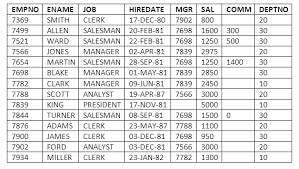 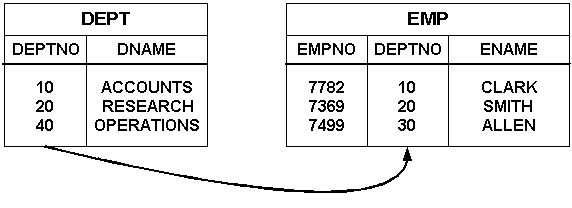

The 10 Steps of SQL Execution:
- FROM The database identifies and gathers the base table(s) or views specified in the query.
- ON If you are joining tables, the database evaluates the join conditions (like d.deptno = e.deptno).
- JOIN The database merges the data from the tables together based on the ON conditions.
- WHERE The database performs a row-by-row filter. It immediately throws away any individual records that do not meet the criteria (like e.sal > 2000).
- GROUP BY The remaining rows are grouped and clustered together into distinct buckets based on the specified columns.
- HAVING The database filters the newly formed groups using aggregate conditions (like HAVING COUNT(empno) > 5). Individual rows cannot be filtered here.
- SELECT The database finally looks at the columns you actually asked for. It calculates mathematical expressions, processes aliases, and evaluates aggregate
  functions (like COUNT(), SUM(), AVG()) on the grouped data.
- DISTINCT If specified, duplicate rows are removed from the final result set.
- ORDER BY The final results are sorted in ascending or descending order. (This is why you can use SELECT column aliases inside ORDER BY).
- LIMIT / OFFSETThe database truncates the final output to return only the requested number of rows.

## Queries
- SELECT * FROM emp WHERE sal > 2000;
- select * from emp e, dept d where e.deptno = d.deptno ;
- SELECT e.ename, d.dname  FROM emp e  JOIN dept d ON e.deptno = d.deptno;
- SELECT deptno, SUM(sal), AVG(comm)  FROM emp GROUP BY deptno;
- SELECT ename FROM emp WHERE ename LIKE 'S%';
- SELECT ename FROM emp WHERE ename LIKE '_a%';
- SELECT ename, sal FROM emp WHERE sal > (SELECT AVG(sal) FROM emp);
- SELECT e.empno, e.ename, d.dname, d.loc FROM emp e INNER JOIN dept d ON e.deptno = d.deptno;
- select count(*) from emp where comm is NULL or comm = 0;
- Inner Join
    - SELECT e.ename, d.dname FROM emp e JOIN dept d ON e.deptno = d.deptno;
    - SQL compares each employee row with department rows.
- Left Join
    - SELECT d.dname,  e.ename FROM dept d LEFT JOIN emp e ON d.deptno = e.deptno;
    - Take ALL rows from LEFT table (dept) Even if no employee exists
- Employees earning above department average
    - SELECT e1.ename, e1.sal,e1.deptno FROM emp e1 WHERE e1.sal >( SELECT AVG(e2.sal)   FROM emp e2    WHERE e1.deptno = e2.deptno);
    - SELECT ename, sal, deptno FROM ( SELECT ename, sal, deptno, AVG(sal) OVER(PARTITION BY deptno) AS dept_avg FROM emp) e WHERE sal > e.dept_avg; -- (Faster)
- Find highest salary employee
    - SELECT * FROM emp ORDER BY salary DESC LIMIT 1;
- Count employees per department
    - SELECT deptno,  COUNT(*) AS total FROM emp GROUP BY deptno;
    - ~~SELECT d.dname, COUNT(e.empno) FROM dept d JOIN emp e on d.deptno = e.deptno GROUP BY d.dname;~~ (Over thinking. It can be done without JOIN)
- Department-wise maximum salary
     - SELECT deptno,   MAX(salary) AS max_salary FROM emp GROUP BY deptno;
- Employees earning above department average
    - SELECT e1.ename,       e1.salary,       e1.deptno FROM emp e1 WHERE salary > (    SELECT AVG(e2.salary)    FROM emp e2    WHERE e1.deptno = e2.deptno );
    - SELECT ename, sal, deptno, avg_sal FROM (SELECT ename, sal, deptno, AVG(sal) OVER (PARTITION BY deptno) AS avg_sal FROM emp) temp_table WHERE sal > avg_sal;
      `(FASTER)`

      
- List out Deptno, Deptname, count of employees having salary > 2000
    -  select count(*) as empCount,d.deptno, avg(e.sal) as avgSal, d.dname  from emp e, dept d   where e.empno in (select empno from emp where sal > 2000) and  d.deptno = e.deptno group by d.deptno, d.dname;
    -  SELECT d.deptno, d.dname AS deptname, COUNT(e.empno) AS employee_count FROM dept d JOIN emp e ON d.deptno = e.deptno WHERE e.sal > 2000 GROUP BY d.deptno, d.dname; Explanation below:

`The SQL Order of ExecutionSQL does not read a query from top to bottom (Select down to Where). It executes in this specific order:FROM & JOIN: SQL first merges your dept and emp tables together into one massive temporary dataset.WHERE e.sal > 2000 (Row-by-Row Filter): This is the key. SQL goes through that dataset row-by-row right now. It immediately throws away any individual employee who makes 2000 or less.GROUP BY d.deptno: SQL takes the remaining high-earning employees and groups them by their department.SELECT ... COUNT(e.empno) (Aggregation): Finally, SQL looks at each department group and counts how many employee rows are left inside it.Because the row-by-row filter (WHERE) happens in Step 2, and the aggregation (COUNT) happens later in Step 4, they never conflict with each other.`


### Query
- SELECT d.dname AS Department_Name, COUNT(e.empno) AS Total_Employees FROM emp e JOIN dept d ON e.deptno = d.deptno GROUP BY d.dname;

#### Query Exp
- Breakdown of the Query
    - JOIN: Connects the emp table (employees) with the dept table (departments) so you can access the dname column.
    - GROUP BY: Organizes the result set by the department name.
    - Aggregate Function: Use COUNT() to see the number of employees, or SUM(sal) to see total department salary.      
- Common Variations
    - Total Salary per Department:SELECT d.dname, SUM(e.sal) FROM emp e JOIN dept d ON e.deptno = d.deptno GROUP BY d.dname;
    - Highest Salary per Department:SELECT d.dname, MAX(e.sal) FROM emp e JOIN dept d ON e.deptno = d.deptno GROUP BY d.dname;
    - Filter Groups: To only see departments with more than 5 employees, add HAVING COUNT(e.empno) > 5 after the GROUP BY clause.

- Show the minimum, maximum and average salary of managers.
  - SELECT MIN(sal) AS MINIMUM_SALARY, MAX(sal) AS MAXIMUM SALARY, AVG(sal) AS AVERAGE_SALARY FROM emp;`
- Count the number of clerks in the organization.
  - SELECT COUNT(*) FROM emp WHERE job = 'CLERK';
- Display the designation-wise list of employees with name, salary and date of joining.
  - SELECT job,ename, sal, hiredate FROM emp ORDER BY job;
- Count the number of employees who are not getting commission.
  - SELECT COUNT(*) FROM emp WHERE comm IS NULL;
- Show the average salary for all departments having salary > 2000.
  - SELECT deptno, AVG(sal) AS avg_sal FROM emp GROUP BY deptno HAVING AVG(sal) > 2000;
- List the count of employees grouped by DeptID.
  - SELECT deptno, COUNT(empno) AS emp_number FROM emp GROUP BY deptno;
- Display the maximum salary of employees in each department.
  - SELECT deptno, MAX(sal) AS MAX_SALARY FROM emp GROUP BY deptno;
- Display the name of employees along with their designation and department name.
  - SELECT e.ename, e.job, d.dname FROM emp e JOIN dept d ON e.deptno = d.deptno ORDER BY ename;
- Count the number of employees working in ACCOUNTS department.
  - SELECT d.dname, COUNT(e.empno) FROM dept d JOIN emp e ON d.deptno = e.deptno WHERE dname = 'ACCOUNTING' GROUP BY d.dname;

## 

Execution Order
    -  FROM -> SELECT -> ORDER BY
## GroupBy + Having
    - FROM -> GROUP BY -> HAVING -> SELECT
    - WHERE - individual rows
    - HAVING - groups
## Real order
    1. FROM
    2. JOIN
    3. ON
    4. WHERE
    5. GROUP BY
    6. HAVING
    7. SELECT
    8. ORDER BY
    9. LIMIT 

# Queries
- Manisha
    - Count the number of employees working in Accounts department.
        - select count(*) from emp where deptno in (select deptno from dept where dname ='ACCOUNTING')
    - Create another column adding sal & comm
        - ALTER TABLE emp ADD dsal DECIMAL(10,2);
        - UPDATE emp SET dsal = sal + IFNULL(comm,0);
- Aleita
    - show employee name, job, salary and location of employees whose salary is less than 1000
    - SELECT e.ename, e.job, e.sal, d.loc from emp e, dept d where e.deptno=d.deptno and e.sal < 1000;
- Muhammad
    - emp whose sal is > avg(sal)
    - select empno, ename, sal from emp where sal > (select avg(sal) from emp);
- Khulan
    - Employees earning more than manager
    - select e.empno, e.ename as empName, e.job, e.sal, e.mgr, m.ename as MENAME, m.job as MJOB, m.sal as MSAL from emp e, emp m where e.mgr = m.empno  and e.sal >         m.sal;
    - SELECT e.empno, e.ename AS empName, e.job, e.sal, e.mgr, m.ename AS MENAME, m.job AS MJOB, m.sal AS MSAL FROM emp e INNER JOIN emp m ON e.mgr = m.empno
      WHERE e.sal > m.sal;

- Taherra
    - Minimum, maximum, and average salary of managers
    - select avg(sal), min(sal), max(sal), count(*) from emp where job = 'MANAGER';
- Ibrahim
    - max salary from each department
    - select d.dname, max(e.sal) as MaxSal from emp e, dept d where e.deptno = d.deptno group by d.dname;
    - select d.dname, max(e.sal) from emp e, dept d where d.deptno = e.deptno group by  d.dname;
- Sevket
    -  Names, jobs, and salaries of all employees in Department 20 and highest salary at the top
    -  select ename, job, sal, deptno  from emp where deptno in ('20') order by sal desc limit 2 ;
- Rita
- Upendo
- others
    - select empno, ename, sal, comm, sal + IFNULL(COMM,0) as DSAL from emp;
- Mesret
    - ?
- Blaandina
- Fardous
- Farzana
- 